## Basic Setup

In [9]:
import os
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from keras.layers import BatchNormalization
from keras.optimizers import SGD
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

os.chdir('../../../../') # move four level up to the base pathfrom src.utils import load_and_preprocess_images
from src.utils import load_and_preprocess_images
from src.model_evaluation import evaluate_model, plot_history

In [10]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [11]:
model_name = '1_synthetic_eyes'
transfer_learning_stage = '1_full_network'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/Unity_Data_Test_Train'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet'

In [12]:
comment = "afternoon run"
model_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [13]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
LOSS_FUNCTION = 'sparse_categorical_crossentropy'

FT_EPOCHS = 50
FT_LEARNING_RATE = 0.00001
OPTIMIZER = SGD(learning_rate=FT_LEARNING_RATE)

In [14]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=20, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

In [15]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 4743 files belonging to 2 classes.
Using 3795 files for training.
Found 4743 files belonging to 2 classes.
Using 948 files for validation.
Found 1187 files belonging to 2 classes.


## Finetuning the Pre-Trained Model

In [18]:
# define the path to the pretrained model
pretrained_model_path = repo_path + '/models/cnn/1_synthetic_eyes/0_last_layers/weights/afternoon run_model.keras'

# load the model
model = tf.keras.models.load_model(pretrained_model_path, compile=True)

# get benchmark results by evaluating the model on the test set
evaluate_model(model, synth_test_data)

19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 585ms/step - accuracy: 0.9507 - loss: 6.8038
Test loss: 6.88775634765625
Test accuracy: 0.92586350440979


In [19]:
# define the path to the pretrained model
pretrained_model_path = repo_path + '/models/cnn/1_synthetic_eyes/0_last_layers/weights/afternoon run_model.keras'

# load the model
model = tf.keras.models.load_model(pretrained_model_path, compile=False)

# unfreeze all layers which are not BN layers
for layer in model.layers:
    if isinstance(layer, BatchNormalization): # freeze BN layers
        layer.trainable = False
    else: # unfreeze all other layers
        layer.trainable = True

# display the summary if needed
# pretrained_model.summary(show_trainable=True)

In [20]:
# compile the model with the same optimizer and loss function
model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER, metrics=['accuracy'])

# train the entire model with the same data but lower learning rate
history = model.fit(
    synth_train_data,
    validation_data=synth_valid_data,
    epochs=FT_EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr] # removed the checkpoint for now
    )

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 288s 5s/step - accuracy: 0.9416 - loss: 6.8249 - val_accuracy: 0.9314 - val_loss: 6.8718 - learning_rate: 1.0000e-05
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.9462 - loss: 6.8122 - val_accuracy: 0.9314 - val_loss: 6.8655 - learning_rate: 1.0000e-05
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 245s 4s/step - accuracy: 0.9440 - loss: 6.8168 - val_accuracy: 0.9346 - val_loss: 6.8546 - learning_rate: 1.0000e-05
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.9449 - loss: 6.8051 - val_accuracy: 0.9304 - val_loss: 6.8722 - learning_rate: 1.0000e-05
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 242s 4s/step - accuracy: 0.9401 - loss: 6.8164 - val_accuracy: 0.9335 - val_loss: 6.8626 - learning_rate: 1.0000e-05
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.9421 - loss: 6.8164 - val_accuracy: 0.9325 - val_loss: 6.8726 - learning_rate: 1.0000e-05
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 249s 4s/step - accuracy: 0.9460 

In [21]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [22]:
# load the best model
model.load_weights(ckpt_file_path)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/1_synthetic_eyes/1_full_network/ckpt/afternoon run_checkpoint.model.keras'

In [23]:
# save the model
model.save(model_file_path)

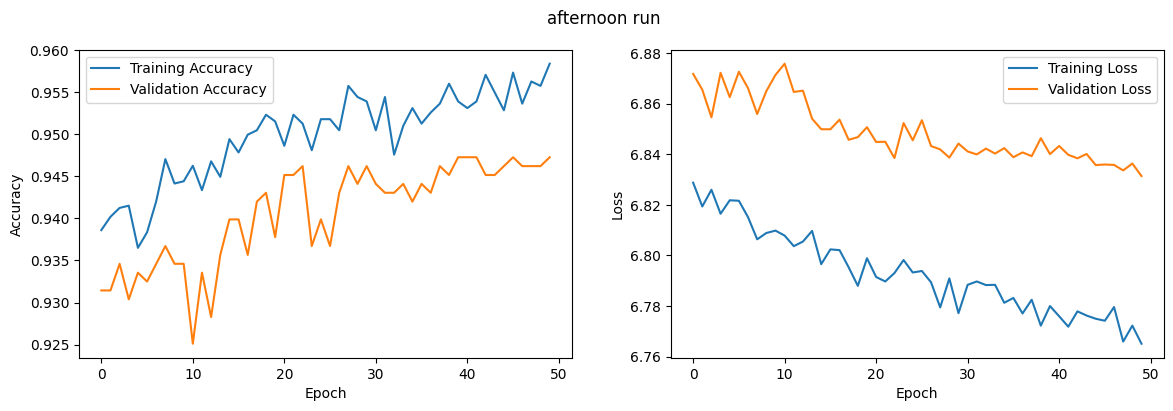

Best train_accuracy: 0.9584
Best train_loss: 6.7651
Best val_accuracy: 0.9473
Best val_loss: 6.8314
Last improvement at epoch: 40


In [24]:
plot_history(comment=comment, history=history)

In [25]:
evaluate_model(model, synth_test_data)

19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9612 - loss: 6.7777
Test loss: 6.845918655395508
Test accuracy: 0.9427127242088318
